# Design your own synthetic radio

`getting_started.ipynb` uses profiles measured from real hardware. This notebook
builds a transmitter **that does not exist**, from a dictionary you write
yourself.

That is what you want when you need:

- a **controlled fleet** — devices differing in exactly one impairment, so a
  classifier's accuracy can be attributed to that impairment and nothing else
- a **sweep** — the same device at ten SNRs, or with ISI scaled from zero
- a **stress case** — an impairment larger than anything in the measured set

The chain is unchanged. Only where the numbers come from changes.

## Setup

In [1]:
import copy
import json
import sys
from pathlib import Path

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

sys.argv = ["notebook"]
sys.path.insert(0, ".")
sys.path.insert(0, "PA_modelling_with_GMP")

import synth_dataset as generator

IDEAL_QPSK = np.array([1 + 1j, 1 - 1j, -1 + 1j, -1 - 1j]) / np.sqrt(2)
print(f"burst = {generator.BURST_LEN} samples at {generator.FS/1e6:.0f} MHz")

burst = 6500 samples at 5 MHz


## 1. The profile schema

A profile is a flat dictionary. Every key below is required by `synth_run`;
there are no optional extras to discover later.

| group | keys | meaning |
| --- | --- | --- |
| identity | `radio`, `config`, `fc_hz` | labels, and the carrier that scales the transient |
| oscillator | `ref_ppm`, `clock_offset_ppm`, `clock_mismatch_ppm` | one crystal; the clock follows the reference |
| sampling | `cp0_samp`, `phi0_rad` | where the receive grid and carrier phase start |
| IQ | `iq_amp_db`, `iq_phase_deg` | modulator imbalance |
| leakage / DC | `lo_leak_dbc`, `leak_phase_rad`, `rx_dc_frac`, `dc_phase_rad` | additive tones |
| linear distortion | `isi_taps` | symbol-spaced complex taps, normalised to the main tap |
| transient | `settling`, `settling_shape` | complex polynomial in burst position — mostly phase |
| PA | `pa_kind`, `pa_b_re`, `pa_b_im`, `pa_cubic_gain`, `pa_A` | memoryless cubic |
| phase noise | `pn_mask`, `pn_slope_db_dec`, `pn_level_db`, `pn_level_shared`, `pn_tangential_deg`, `pn_radial_pct` | power-law mask as (Hz, dBc/Hz) points |
| noise | `snr_db` | sets the AWGN variance |

`ripple_fir` is deliberately absent: it is a *measured* receiver artefact, and a
hand-built radio has no reason to carry one.

### Write the profile

Every number here is yours to choose. These start near the measured fleet so
the result is realistic, but nothing stops you moving them.

In [2]:
my_radio = dict(
    # --- identity -------------------------------------------------------
    radio="MYRADIO01", config="89_433", fc_hz=433.92e6,

    # --- reference oscillator: one crystal drives CFO and the sampling clock
    ref_ppm=-1.50,              # carrier offset in ppm
    clock_offset_ppm=0.01,      # fixed gap between the two estimators
    clock_mismatch_ppm=-1.49,   # overwritten per run when kind is "derived"

    # --- where the receiver's grid happens to land ------------------------
    cp0_samp=0.0, phi0_rad=0.0,

    # --- IQ modulator imbalance ------------------------------------------
    iq_amp_db=0.05, iq_phase_deg=0.40,

    # --- additive tones ---------------------------------------------------
    lo_leak_dbc=-60.0, leak_phase_rad=0.0,
    rx_dc_frac=1e-5, dc_phase_rad=0.0,

    # --- linear distortion: taps are RELATIVE to the main tap -------------
    isi_taps={"lags": [-1, 1], "c": [[0.002, 0.010],      # lag -1: re, im
                                     [0.030, 0.001]]},    # lag +1: re, im

    # --- burst transient: complex cubic, near-imaginary = almost pure phase
    settling=[[0.0, -0.20], [0.0, 0.40], [0.0, -0.21]],
    settling_shape=None,

    # --- power amplifier: memoryless cubic --------------------------------
    pa_kind="cubic", pa_b_re=-0.15, pa_b_im=0.0,
    pa_cubic_gain=7.1, pa_A=1e6,

    # --- phase noise: (offset Hz, dBc/Hz) points --------------------------
    pn_mask=[[100.0, -70.0], [1000.0, -78.0], [10000.0, -86.0],
             [100000.0, -94.0], [500000.0, -100.0]],
    pn_slope_db_dec=-7.7, pn_level_db=0.0, pn_level_shared=False,
    pn_tangential_deg=1.5, pn_radial_pct=0.0,

    # --- receiver noise ---------------------------------------------------
    snr_db=42.0,
)
print(f"{len(my_radio)} keys")

29 keys


### Write the variation spec

One entry per parameter that moves between runs. Anything you leave as `fixed`
stays at its profile value forever — which is exactly what you want for the
impairments you are trying to isolate.

In [3]:
my_variation = {
    # wanders slowly across runs, like a real crystal
    "ref_ppm": {"kind": "ar1", "sd": 0.001, "phi": 0.30},
    "clock_mismatch_ppm": {"kind": "derived"},

    # re-measured every run, independent each time
    "iq_amp_db":    {"kind": "gauss", "sd": 0.02},
    "iq_phase_deg": {"kind": "gauss", "sd": 0.13},
    "snr_db":       {"kind": "gauss", "sd": 0.20},

    # bounded: a Gaussian tail would otherwise draw unphysical leakage
    "lo_leak_dbc":  {"kind": "gauss", "sd": 2.0, "lo": -75.0, "hi": -50.0},

    # unsynchronised receiver: no preferred phase
    "cp0_samp":       {"kind": "uniform", "lo": -0.5, "hi": 0.5},
    "phi0_rad":       {"kind": "uniform", "lo": 0.0, "hi": 2 * np.pi},
    "leak_phase_rad": {"kind": "uniform", "lo": 0.0, "hi": 2 * np.pi},
    "dc_phase_rad":   {"kind": "uniform", "lo": 0.0, "hi": 2 * np.pi},

    # held constant - these are the device's fingerprint
    "isi_taps":          {"kind": "fixed"},
    "pa_b_re":           {"kind": "fixed"},
    "pa_b_im":           {"kind": "fixed"},
    "rx_dc_frac":        {"kind": "fixed"},
    "pn_level_db":       {"kind": "fixed"},
    "pn_tangential_deg": {"kind": "fixed"},
    "pn_radial_pct":     {"kind": "fixed"},
}

generator.describe(my_radio, my_variation)


MYRADIO01 / 89_433   (hand-built, fc 433.92 MHz)
  parameter                  value   variation
  ref_ppm                     -1.5   AR(1) sd=0.001 phi=0.300
  clock_mismatch_ppm         -1.49   derived from ref_ppm (shared reference)
  iq_amp_db                   0.05   Gaussian sd=0.02
  iq_phase_deg                 0.4   Gaussian sd=0.13
  snr_db                        42   Gaussian sd=0.2
  lo_leak_dbc                  -60   Gaussian sd=2
  cp0_samp                       0   Uniform [-0.5, 0.5]
  phi0_rad                       0   Uniform [0, 6.283]
  rx_dc_frac                 1e-05   held at the profile value
  pa_b_re                    -0.15   held at the profile value
  pa_b_im                        0   held at the profile value
  pn_level_db                    0   held at the profile value
  pn_radial_pct                  0   held at the profile value
  isi_taps                           fixed, 2 complex taps
      lag -1    -39.83 dBc     +78.7 deg
      lag +1    -30.45 d

It works exactly like a measured profile — note the header says `hand-built` where a measured one reports how many real runs it came from.

## 2. Generate from it

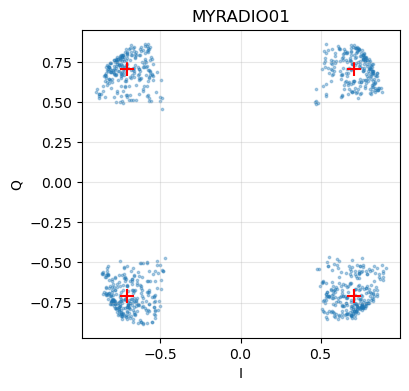

In [4]:
transmitted, received, injected = generator.synth_run(
    my_radio, my_variation, np.random.default_rng(0), {}, n_bursts=4)


def symbols_at_decision_instants(waveform, carrier_offset_hz):
    """Matched-filter one burst, derotate, sample at the symbol instants."""
    index = np.arange(len(waveform))
    derotated = waveform * np.exp(-2j * np.pi * carrier_offset_hz / generator.FS * index)
    filtered = scipy.signal.oaconvolve(derotated, generator.SRRC, mode="full")
    filtered = filtered[generator.MF_DELAY:generator.MF_DELAY + len(waveform)]
    start = generator.N_PRE * generator.SPS
    stop = (generator.N_PRE + generator.N_DATA) * generator.SPS
    return filtered[start:stop:generator.SPS]


def normalised_constellation(received_burst, transmitted_burst, offset_ppm):
    offset_hz = offset_ppm * 1e-6 * my_radio["fc_hz"]
    rx_symbols = symbols_at_decision_instants(received_burst, offset_hz)
    tx_symbols = symbols_at_decision_instants(transmitted_burst, 0.0)
    aligned = rx_symbols * np.exp(-1j * np.angle(np.vdot(tx_symbols, rx_symbols)))
    return aligned / np.sqrt(np.mean(np.abs(aligned) ** 2))


constellation = normalised_constellation(
    received[:generator.BURST_LEN], transmitted[:generator.BURST_LEN],
    injected["ref_ppm"])

plt.figure(figsize=(4.2, 4.2))
plt.scatter(constellation.real, constellation.imag, s=3, alpha=0.35)
plt.scatter(IDEAL_QPSK.real, IDEAL_QPSK.imag, marker="+", c="r", s=90)
plt.gca().set_aspect("equal"); plt.grid(alpha=0.3)
plt.title("MYRADIO01"); plt.xlabel("I"); plt.ylabel("Q")
plt.tight_layout(); plt.show()

## 3. Check you got what you asked for

Never trust a generator you have not round-tripped. Inject a known carrier
offset, measure it back off the synthetic capture with an independent
estimator, and confirm both the sign and the size.

In [5]:
def measure_cfo_hz(burst, nfft=1 << 16):
    """Fourth-power CFO estimator with parabolic peak interpolation.

    QPSK to the fourth power collapses the modulation to a tone at 4x the
    carrier offset. Nothing here knows what was injected.
    """
    segment = burst[generator.N_PRE * generator.SPS:
                    (generator.N_PRE + generator.N_DATA) * generator.SPS]
    spectrum = np.abs(np.fft.fft(segment ** 4, nfft))
    peak = int(np.argmax(spectrum))
    left, centre, right = spectrum[peak - 1], spectrum[peak], spectrum[(peak + 1) % nfft]
    curvature = left - 2 * centre + right
    shift = 0.5 * (left - right) / curvature if curvature != 0 else 0.0
    bin_index = peak + shift
    if bin_index >= nfft / 2:
        bin_index -= nfft
    return bin_index * generator.FS / nfft / 4.0


frozen = {name: {"kind": "fixed"} for name in my_variation}
requested_ppm = np.array([-3.0, -1.5, 0.0, 1.5, 3.0])
measured_hz = []

for ppm in requested_ppm:
    probe = copy.deepcopy(my_radio)
    probe["ref_ppm"] = float(ppm)
    _, probe_rx, _ = generator.synth_run(
        probe, frozen, np.random.default_rng(0), {}, 1)
    measured_hz.append(measure_cfo_hz(probe_rx[:generator.BURST_LEN]))

requested_hz = requested_ppm * 1e-6 * my_radio["fc_hz"]
measured_hz = np.array(measured_hz)

for want, got in zip(requested_hz, measured_hz):
    print(f"  injected {want:+9.2f} Hz   measured {got:+9.2f} Hz   "
          f"error {got - want:+6.2f} Hz")
print(f"\nmean error {np.mean(measured_hz - requested_hz):+.2f} Hz "
      f"(a constant bias is the ESTIMATOR, not the generator)")

  injected  -1301.76 Hz   measured  -1301.47 Hz   error  +0.29 Hz
  injected   -650.88 Hz   measured   -650.58 Hz   error  +0.30 Hz
  injected     +0.00 Hz   measured     +0.47 Hz   error  +0.47 Hz
  injected   +650.88 Hz   measured   +651.10 Hz   error  +0.22 Hz
  injected  +1301.76 Hz   measured  +1302.23 Hz   error  +0.47 Hz

mean error +0.35 Hz (a constant bias is the ESTIMATOR, not the generator)


The errors are sub-Hz on offsets of over a kilohertz, and the residual is
a constant bias rather than a scale error — which tells you it belongs to the
estimator, not to the chain. That is the check to repeat whenever you add an
impairment of your own.

## 4. Turn one impairment at a time

Because everything else is frozen, the difference between these two
constellations is the ISI taps and nothing else.

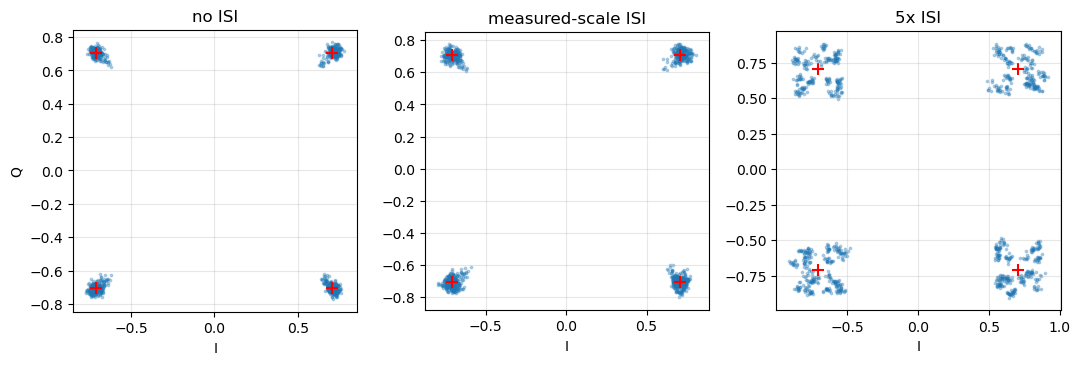

In [6]:
no_isi = copy.deepcopy(my_radio)
no_isi["isi_taps"] = {"lags": [], "c": []}

strong_isi = copy.deepcopy(my_radio)
strong_isi["isi_taps"] = {"lags": [-1, 1], "c": [[0.01, 0.05], [0.15, 0.005]]}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, (title, profile) in zip(axes, [("no ISI", no_isi),
                                       ("measured-scale ISI", my_radio),
                                       ("5x ISI", strong_isi)]):
    tx_b, rx_b, drew = generator.synth_run(
        profile, frozen, np.random.default_rng(0), {}, 1)
    points = normalised_constellation(rx_b[:generator.BURST_LEN],
                                      tx_b[:generator.BURST_LEN], drew["ref_ppm"])
    ax.scatter(points.real, points.imag, s=3, alpha=0.3)
    ax.scatter(IDEAL_QPSK.real, IDEAL_QPSK.imag, marker="+", c="r", s=70)
    ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.set_title(title)
    ax.set_xlabel("I")
axes[0].set_ylabel("Q")
plt.tight_layout(); plt.show()

## 5. Build a fleet

A population of devices is a population of *profiles*. Draw the device-fixed
parameters once per radio — those are the fingerprint — and let the variation
spec handle the rest.

In [7]:
FLEET_SIZE = 6
fleet_rng = np.random.default_rng(20)
fleet = []

for device_index in range(FLEET_SIZE):
    device = copy.deepcopy(my_radio)
    device["radio"] = f"SYN{device_index:02d}"
    # device-fixed draws: these are what separates one unit from another
    device["ref_ppm"] = float(fleet_rng.normal(-1.5, 0.8))
    device["iq_phase_deg"] = float(fleet_rng.normal(0.0, 0.5))
    device["iq_amp_db"] = float(fleet_rng.normal(0.0, 0.05))
    device["lo_leak_dbc"] = float(fleet_rng.uniform(-72, -55))
    device["isi_taps"] = {"lags": [-1, 1],
                          "c": [[float(fleet_rng.normal(0.002, 0.004)),
                                 float(fleet_rng.normal(0.010, 0.004))],
                                [float(fleet_rng.normal(0.030, 0.006)),
                                 float(fleet_rng.normal(0.001, 0.004))]]}
    fleet.append(device)

for device in fleet:
    print(f"{device['radio']}  ref {device['ref_ppm']:+.3f} ppm   "
          f"IQ phase {device['iq_phase_deg']:+.3f} deg   "
          f"leak {device['lo_leak_dbc']:.1f} dBc")

SYN00  ref -1.788 ppm   IQ phase +0.602 deg   leak -63.1 dBc
SYN01  ref -2.299 ppm   IQ phase +0.465 deg   leak -67.4 dBc
SYN02  ref -1.021 ppm   IQ phase +0.009 deg   leak -70.5 dBc
SYN03  ref +0.210 ppm   IQ phase -1.276 deg   leak -66.9 dBc
SYN04  ref -1.364 ppm   IQ phase -1.194 deg   leak -60.0 dBc
SYN05  ref -1.119 ppm   IQ phase +0.752 deg   leak -70.2 dBc


Now record a few runs of each and measure the carrier offset back. This is the space a classifier actually sees: device clusters, widened by run-to-run variation.

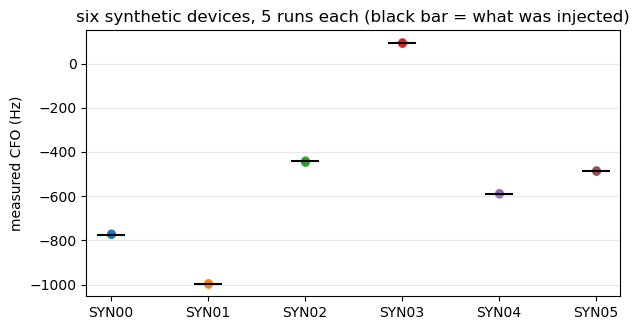

In [8]:
RUNS_PER_DEVICE = 5
measurements = {}

for device in fleet:
    rng = np.random.default_rng(abs(hash(device["radio"])) % 2**32)
    memory = {}
    per_run = []
    for _ in range(RUNS_PER_DEVICE):
        _, run_rx, _ = generator.synth_run(device, my_variation, rng, memory, 1)
        per_run.append(measure_cfo_hz(run_rx[:generator.BURST_LEN]))
    measurements[device["radio"]] = np.array(per_run)

plt.figure(figsize=(6.4, 3.4))
for position, device in enumerate(fleet):
    values = measurements[device["radio"]]
    plt.scatter(np.full_like(values, position), values, s=26, alpha=0.75)
    plt.scatter([position], [device["ref_ppm"] * 1e-6 * device["fc_hz"]],
                marker="_", s=420, c="k")
plt.xticks(range(FLEET_SIZE), [d["radio"] for d in fleet])
plt.ylabel("measured CFO (Hz)"); plt.grid(alpha=0.3, axis="y")
plt.title("six synthetic devices, 5 runs each (black bar = what was injected)")
plt.tight_layout(); plt.show()

## 6. Sweep one impairment

The other reason to hand-build: a ladder where exactly one thing changes. Here
SNR, scored by error-vector magnitude.

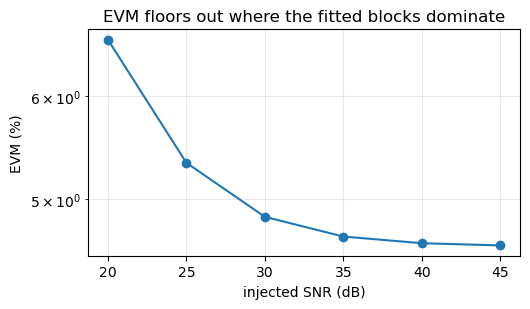

  SNR 20 dB -> EVM  6.63 %
  SNR 25 dB -> EVM  5.33 %
  SNR 30 dB -> EVM  4.85 %
  SNR 35 dB -> EVM  4.68 %
  SNR 40 dB -> EVM  4.63 %
  SNR 45 dB -> EVM  4.61 %


In [9]:
def error_vector_magnitude_pct(points):
    nearest = IDEAL_QPSK[np.argmin(np.abs(points[:, None] - IDEAL_QPSK[None, :]), axis=1)]
    return np.sqrt(np.mean(np.abs(points - nearest) ** 2)) * 100


snr_ladder = [20, 25, 30, 35, 40, 45]
evm_values = []

for snr_db in snr_ladder:
    rung = copy.deepcopy(my_radio)
    rung["snr_db"] = float(snr_db)
    tx_b, rx_b, drew = generator.synth_run(
        rung, frozen, np.random.default_rng(5), {}, 1)
    points = normalised_constellation(rx_b[:generator.BURST_LEN],
                                      tx_b[:generator.BURST_LEN], drew["ref_ppm"])
    evm_values.append(error_vector_magnitude_pct(points))

plt.figure(figsize=(5.4, 3.2))
plt.semilogy(snr_ladder, evm_values, "o-")
plt.xlabel("injected SNR (dB)"); plt.ylabel("EVM (%)")
plt.grid(alpha=0.3, which="both")
plt.title("EVM floors out where the fitted blocks dominate")
plt.tight_layout(); plt.show()

for snr_db, evm in zip(snr_ladder, evm_values):
    print(f"  SNR {snr_db:2d} dB -> EVM {evm:5.2f} %")

EVM falls with SNR and then **floors**: past about 35 dB the noise is no
longer what limits the constellation — the ISI, PA and transient are. That
floor is the device fingerprint, and it is the reason a fingerprinting dataset
needs those blocks rather than AWGN alone.

## 7. Save and reload

A profile is JSON. Store it beside the dataset and the experiment is
reproducible.

In [10]:
profile_path = Path("./my_radio.json")
profile_path.write_text(json.dumps(
    {"profile": my_radio, "variation": my_variation}, indent=1))

restored = json.loads(profile_path.read_text())
_, _, from_original = generator.synth_run(
    my_radio, my_variation, np.random.default_rng(99), {}, 1)
_, _, from_restored = generator.synth_run(
    restored["profile"], restored["variation"], np.random.default_rng(99), {}, 1)

print(f"same draw after a JSON round trip: "
      f"{from_original['ref_ppm'] == from_restored['ref_ppm']}")
profile_path.unlink()

same draw after a JSON round trip: True


## Pitfalls

- **ISI taps are relative to the main tap**, which is implied and not listed.
  A tap of `0.03` means 3 % of the main path, about -30 dBc.
- **`settling` is complex but should be near-imaginary.** The measured devices
  sit within a few degrees of the imaginary axis, i.e. the transient is a phase
  effect. A real-valued settling term would be an amplitude ramp, which is not
  what the hardware does.
- **Bound anything physical.** A Gaussian on LO leakage with no `lo`/`hi` will
  eventually draw a value the hardware could never produce, and that run will
  also break the noise budget.
- **`pn_mask` is in dBc/Hz at offset frequencies**, single-sideband. Points are
  interpolated on a log-log grid.
- **Do not copy `ripple_fir` from a measured profile** unless you also copy the
  taps that were fitted against it. They are a matched pair — injecting one
  without the other double-counts the band shape, and the generator refuses to
  do it.
- **Round-trip every impairment you add.** Section 3 is the template: inject a
  known value, measure it back with an independent estimator, check the sign
  and the magnitude.